# QR2025 results (COSIT 2024 large benchmark)


In [38]:
%run -i "utils.py"

## Large

In [39]:
df = load_results("../data/qr2025/large/")
df['colour'] = 0
df = df[df['repeat'] <= 2] # only use first three repeats

In [40]:
len(df['model'].unique())

22

Combine with the old results published for COSIT24

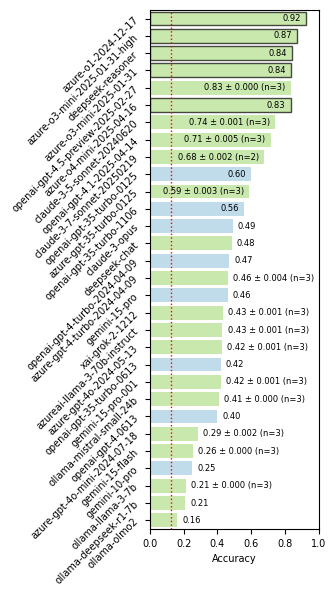

In [41]:
alpha = {
    'model': ['gemini-10-pro', 'openai-gpt-4-0613', 'openai-gpt-35-turbo-0613', 'gemini-15-pro','openai-gpt-4-turbo-2024-04-09','claude-3-opus','openai-gpt-35-turbo-1106','openai-gpt-35-turbo-0125'],
    'score': [0.25, 0.4, 0.42, 0.46, 0.47, 0.49, 0.56, 0.6],
    'repeat': [0,0,0,0,0,0,0,0]
}

alpha = pd.DataFrame(alpha)

alpha['colour'] = 1

df_large = pd.concat([alpha, df[['model', 'score', 'repeat', 'colour']]], ignore_index=True)
plot_model_scores(df_large, fontsize=7,width=3.375,height=6)
plt.tight_layout()
plt.show()

How many models did we test?

In [42]:
len(df_large['model'].unique())

30

## Confusion matrices

In [43]:
def clean_direction(str):
    if str in ['north','south','east','west','north-east','north-west','south-east','south-west']:
        return str
    else:
        return "invalid"

/Users/rblackwell/git/cosit-2024-evaluating-the-ability-of-llms-to-reason-about-cardinal-directions/notebooks/utils.py:1014: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(4, 4))


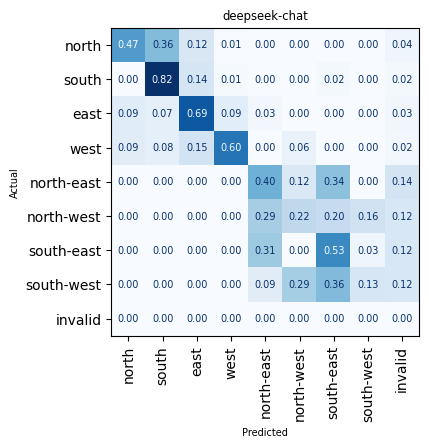

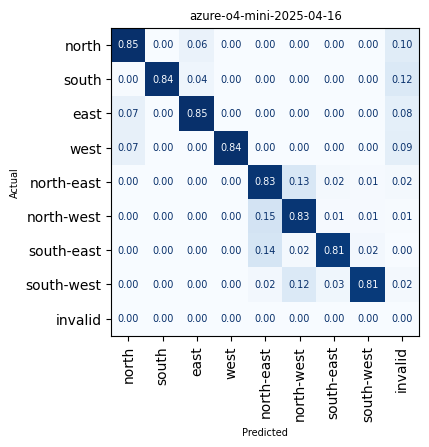

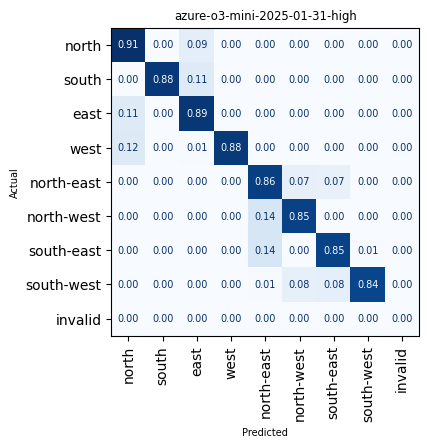

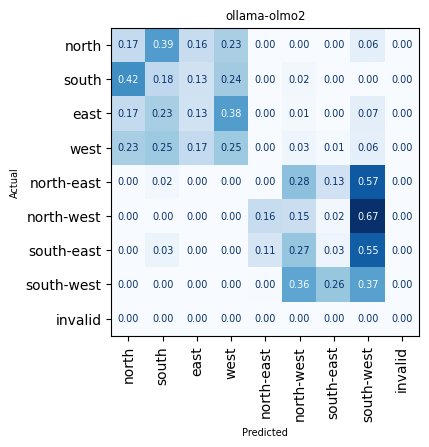

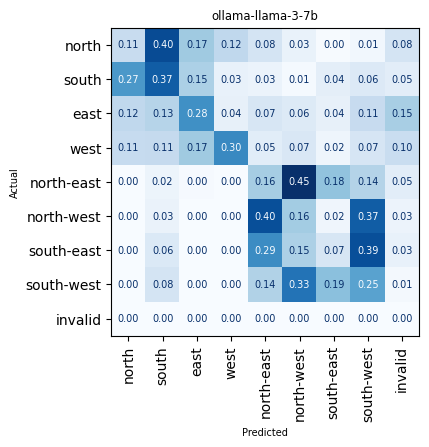

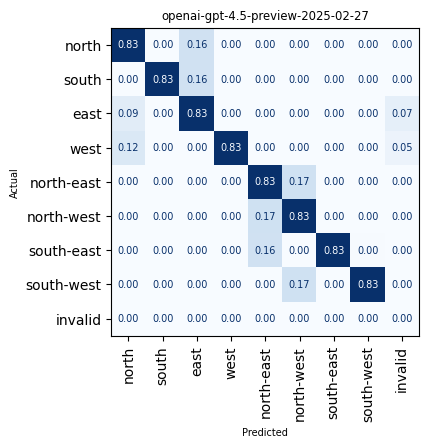

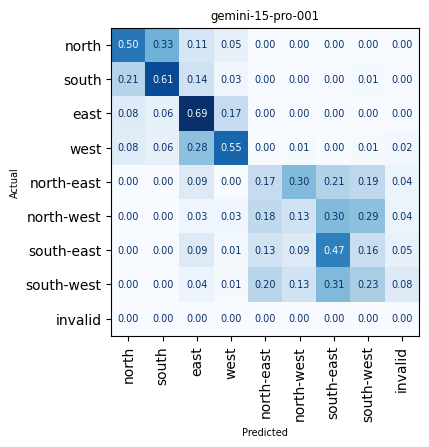

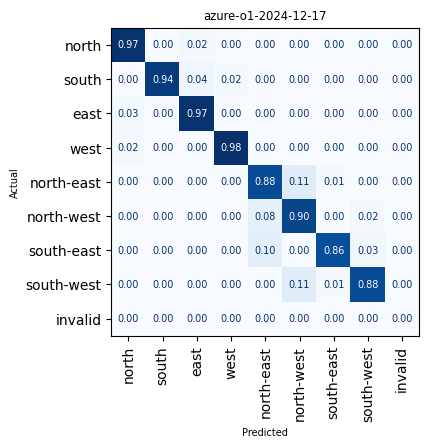

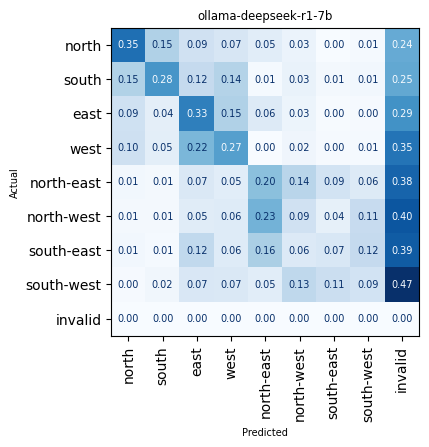

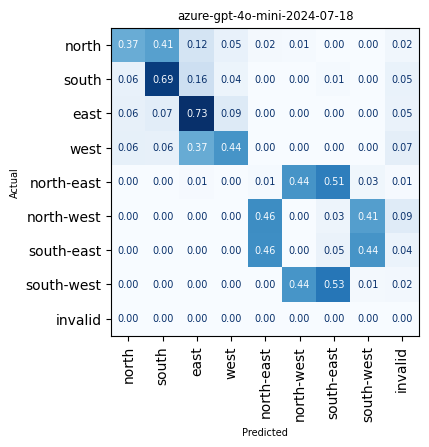

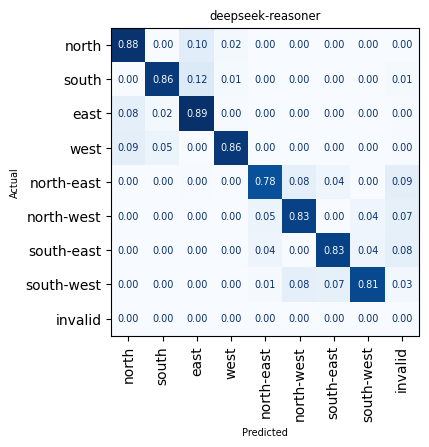

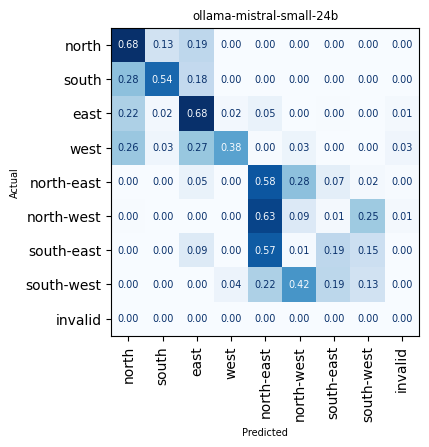

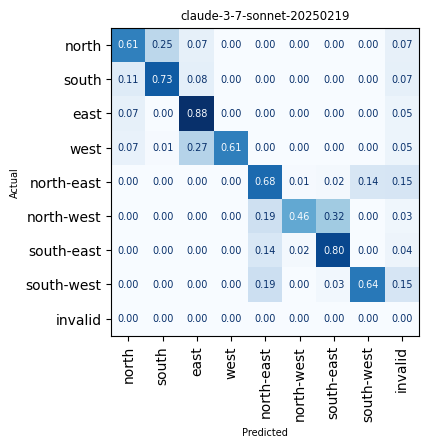

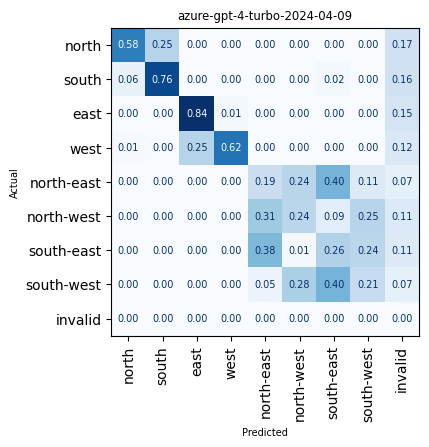

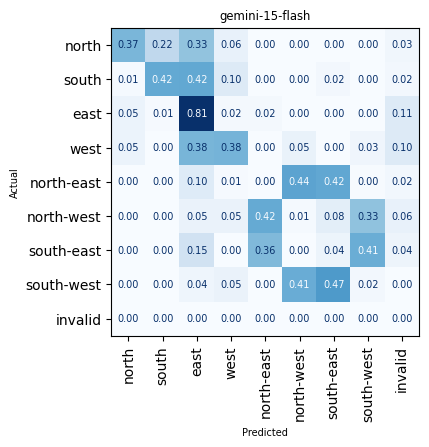

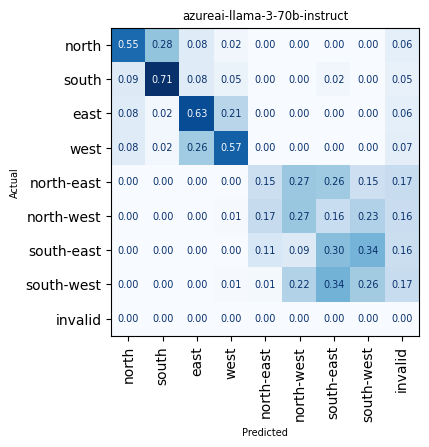

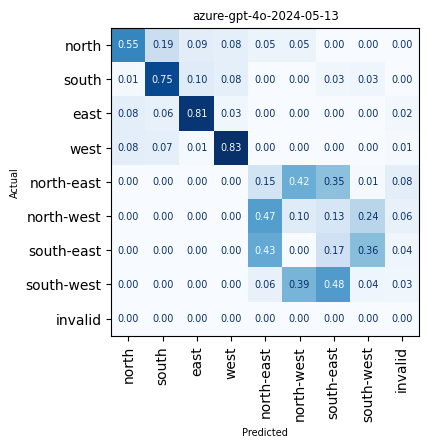

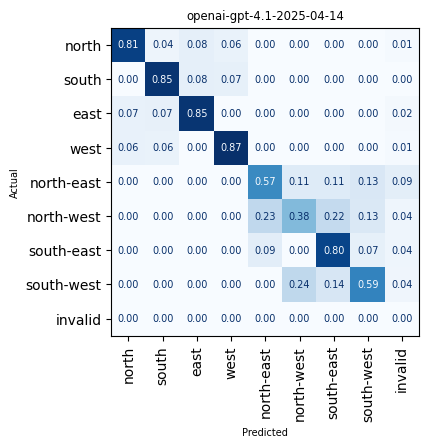

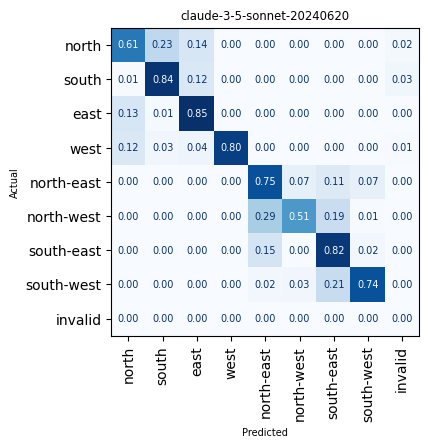

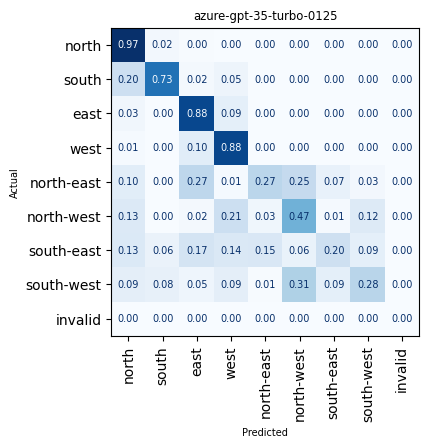

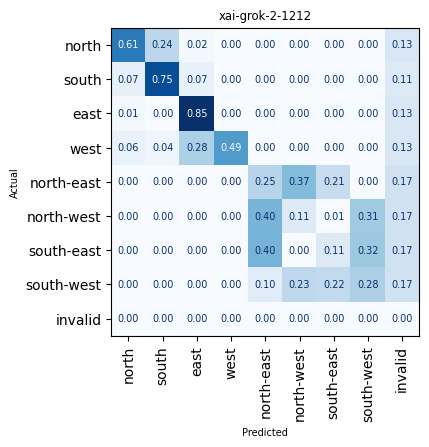

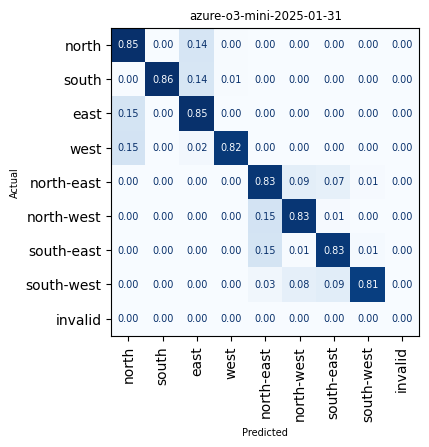

In [44]:
for model in df['model'].unique():
    a = df[df['model'] == model]['correctAnswer'].apply(clean_direction)
    b = df[df['model'] ==  model]['cleanAnswer'].apply(clean_direction)
    my_confusion_matrix(a, b, normalize='true', labels=['north','south','east','west','north-east','north-west','south-east','south-west','invalid'], title= model )

# Locomotion

/Users/rblackwell/git/cosit-2024-evaluating-the-ability-of-llms-to-reason-about-cardinal-directions/notebooks/utils.py:215: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 4))


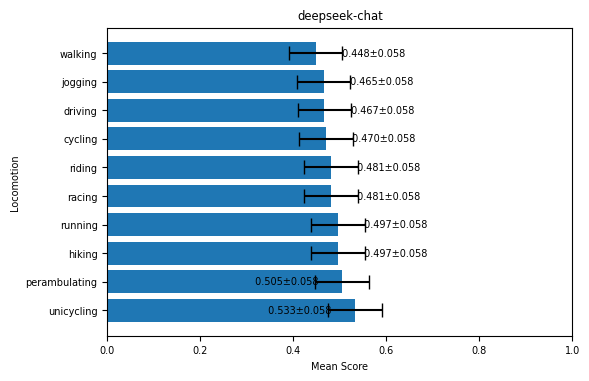

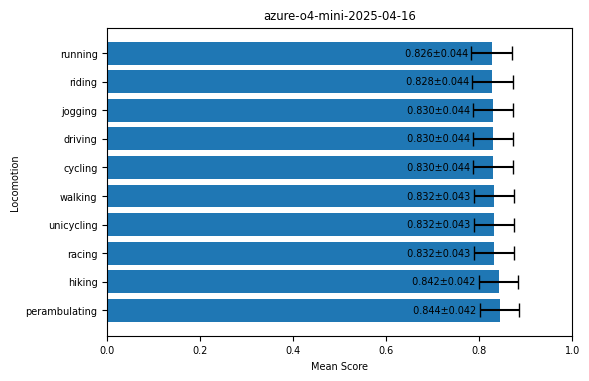

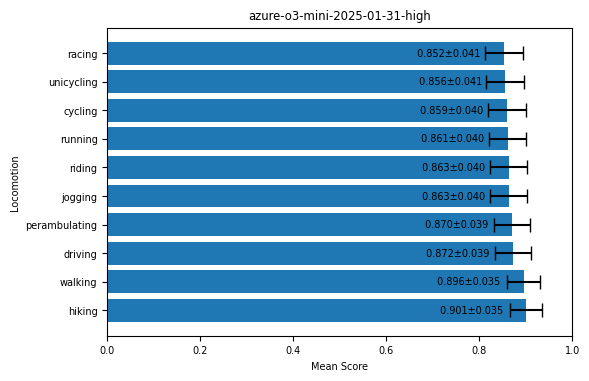

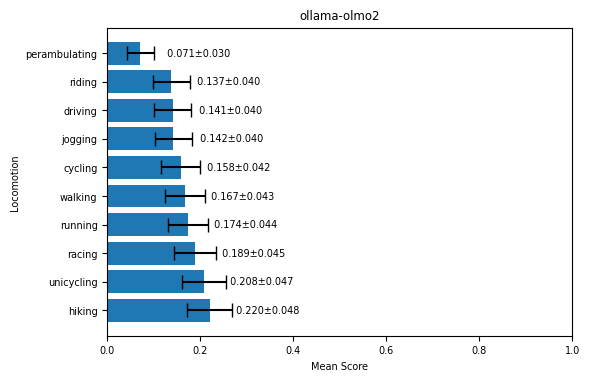

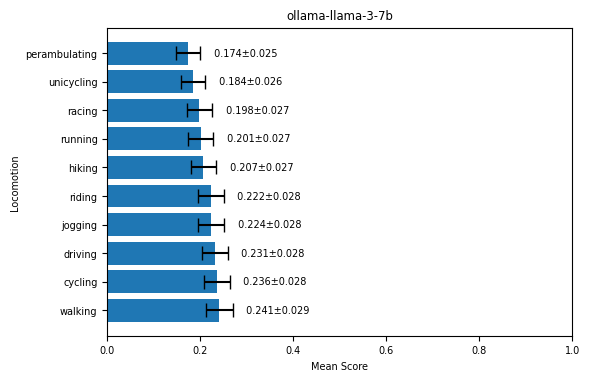

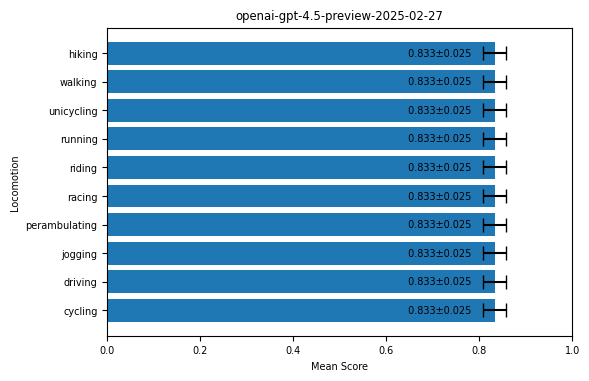

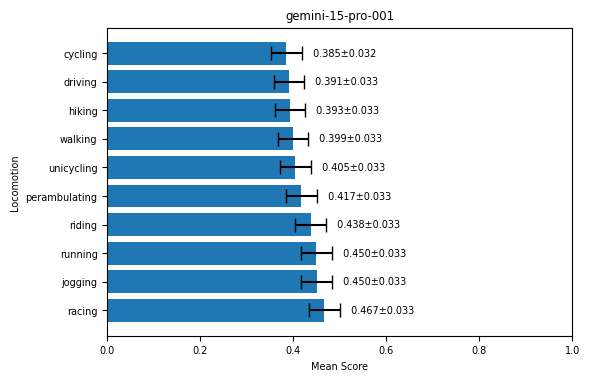

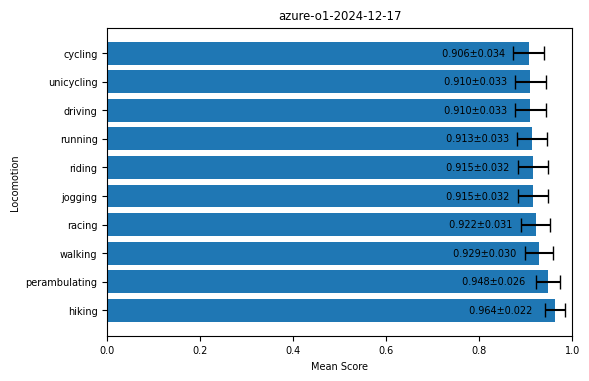

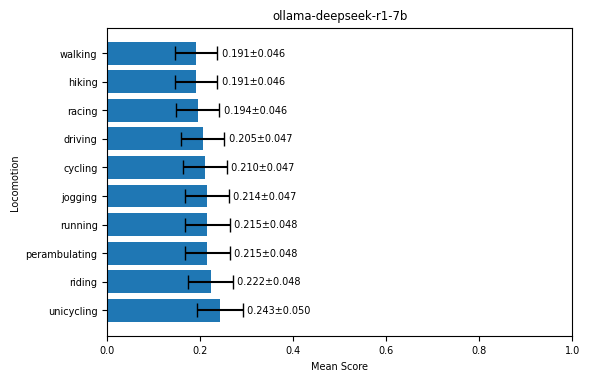

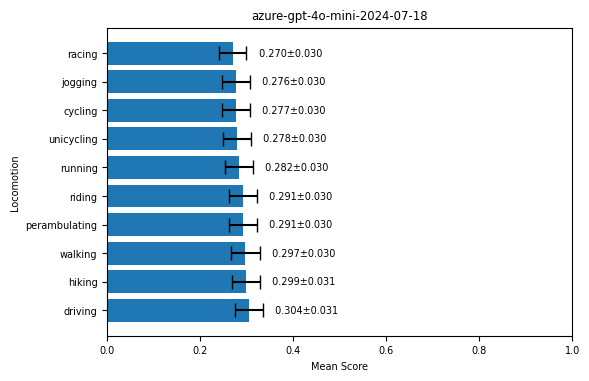

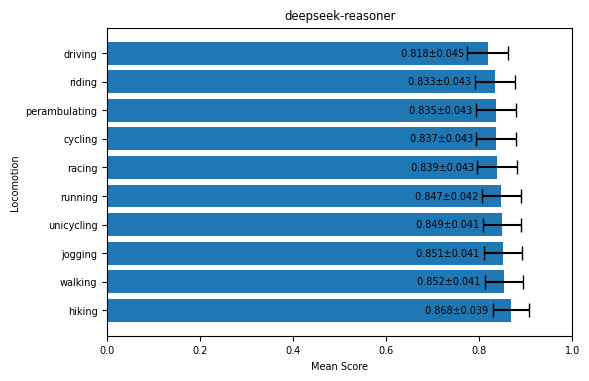

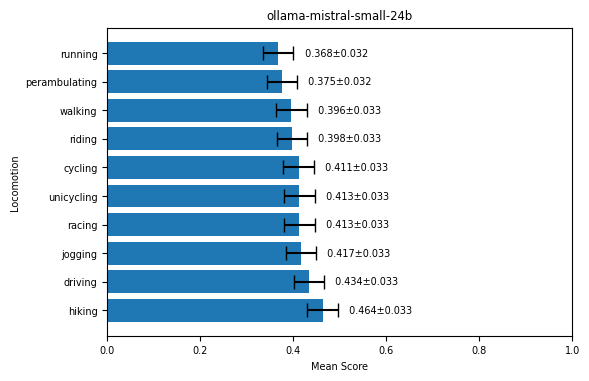

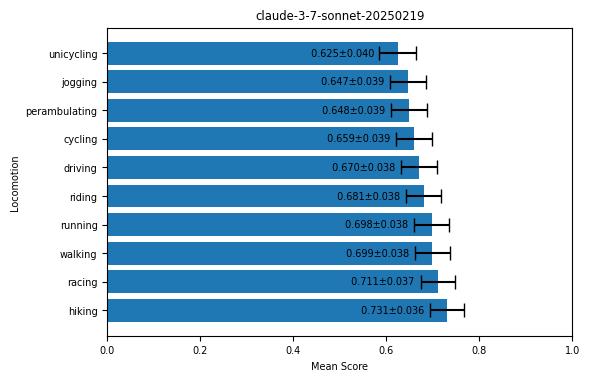

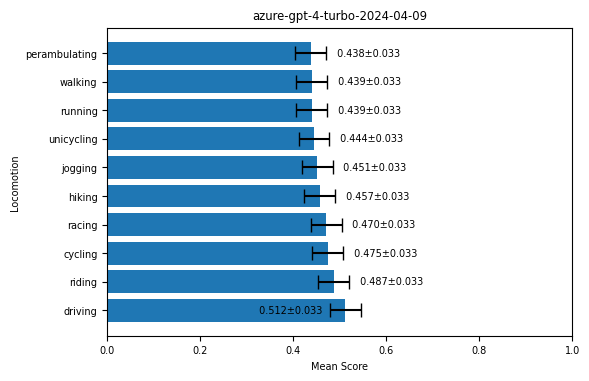

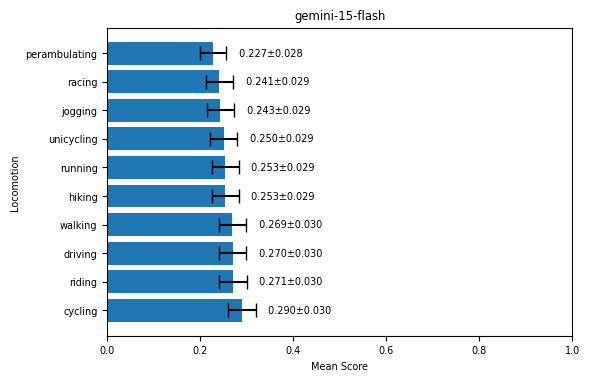

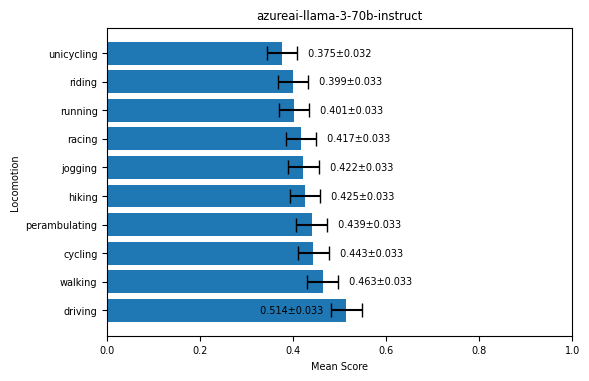

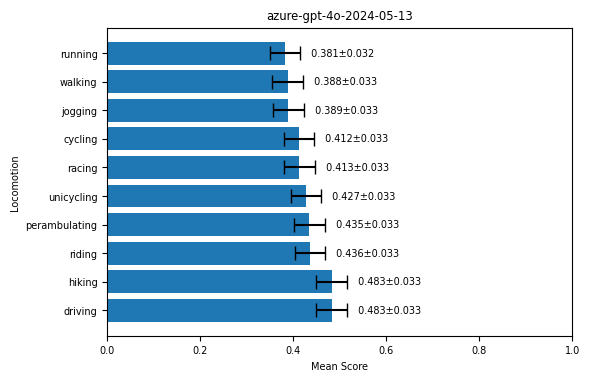

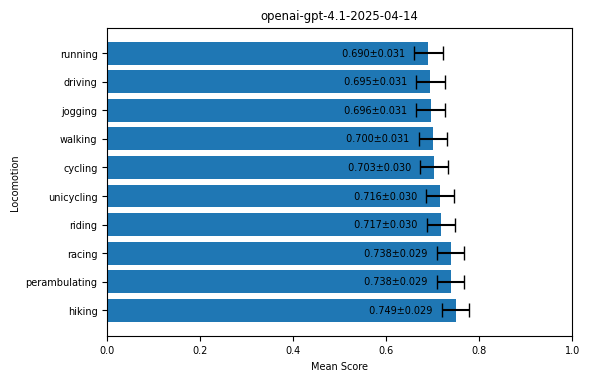

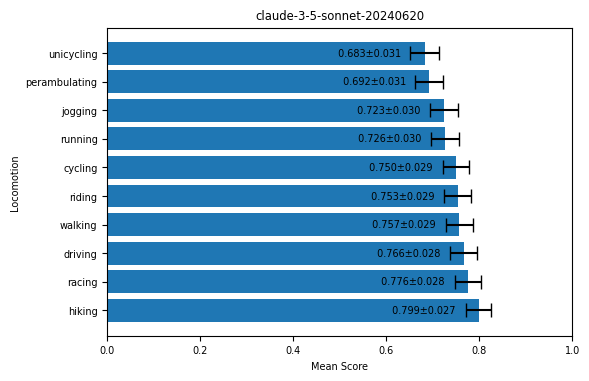

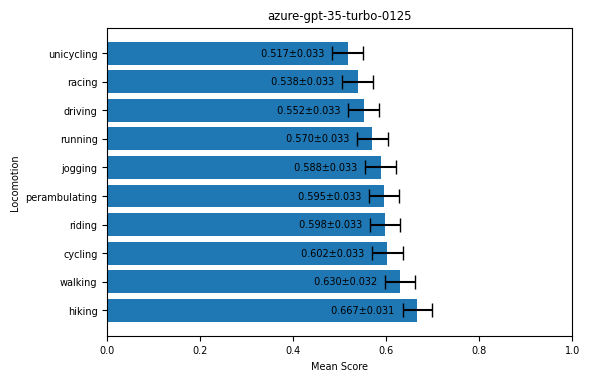

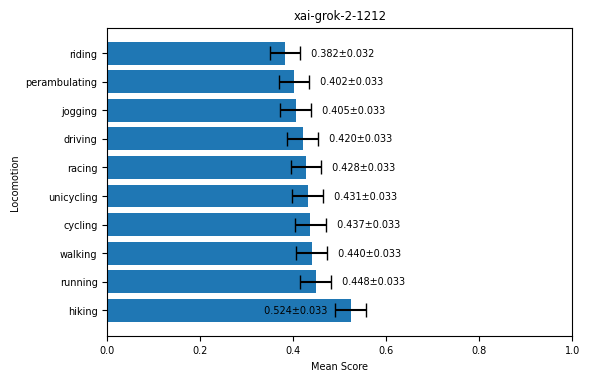

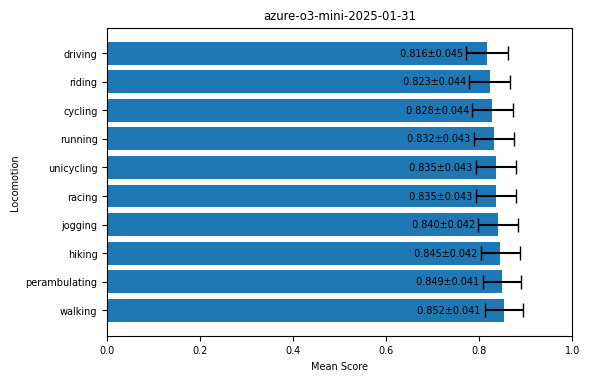

In [45]:
for model in df['model'].unique():
    plot_locomotion(df, model)

model          azure-gpt-35-turbo-0125  azure-gpt-4-turbo-2024-04-09  \
locomotion                                                             
cycling                       0.602431                      0.474537   
driving                       0.551505                      0.511574   
hiking                        0.666667                      0.457176   
jogging                       0.587963                      0.451389   
perambulating                 0.595486                      0.437500   
racing                        0.538194                      0.470486   
riding                        0.597801                      0.487269   
running                       0.570023                      0.439236   
unicycling                    0.517361                      0.444444   
walking                       0.630208                      0.439236   

model          azure-gpt-4o-2024-05-13  azure-gpt-4o-mini-2024-07-18  \
locomotion                                                     

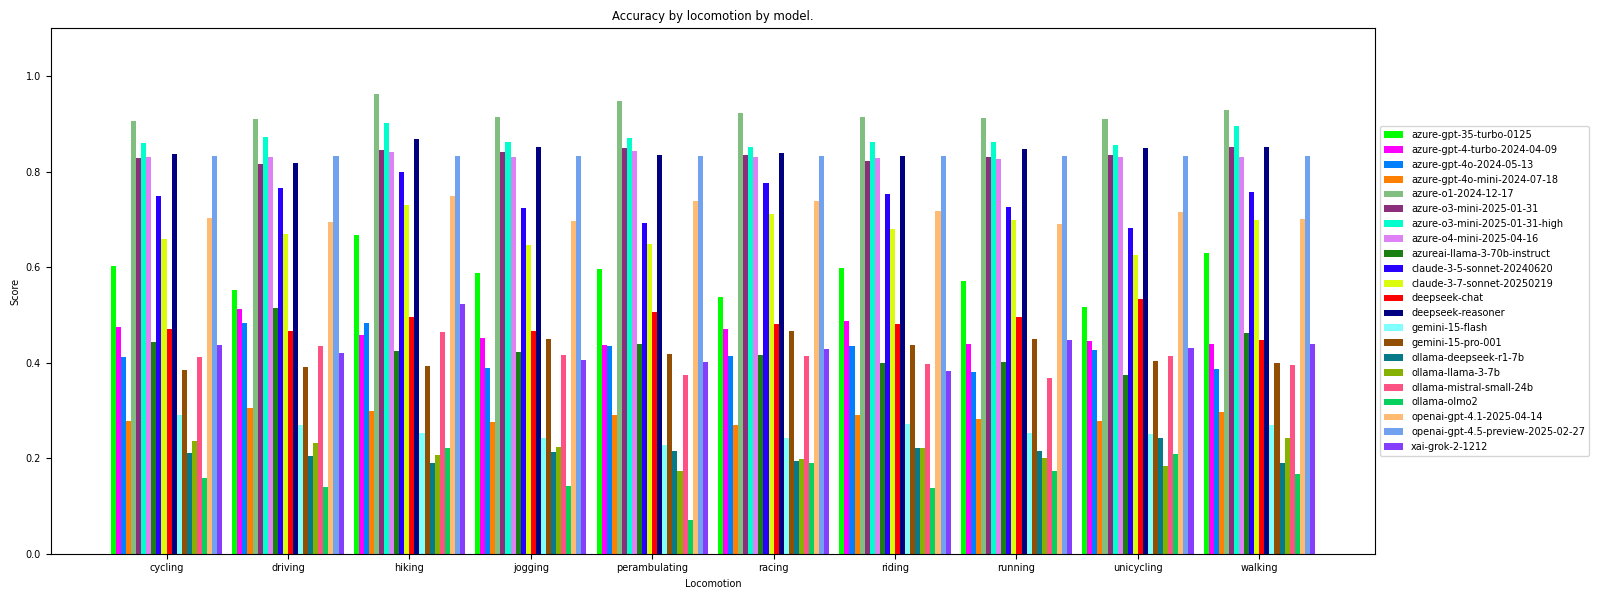

In [46]:
df3 = df.groupby(['locomotion', 'model'])['score'].mean().unstack()
print(df3)
plot_grouped_bar_chart(df3, xlabel="Locomotion",title="Accuracy by locomotion by model.")

# Person

In [47]:
person_mapping = {
    1: 'I am',
    2: 'You are',
    3: 'He is',
    4: 'She is',
    5: 'We are',
    6: 'They are'
}

# Apply the mapping to the 'person' column
df['person'] = df['person'].map(person_mapping)


/Users/rblackwell/git/cosit-2024-evaluating-the-ability-of-llms-to-reason-about-cardinal-directions/notebooks/utils.py:898: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 4))


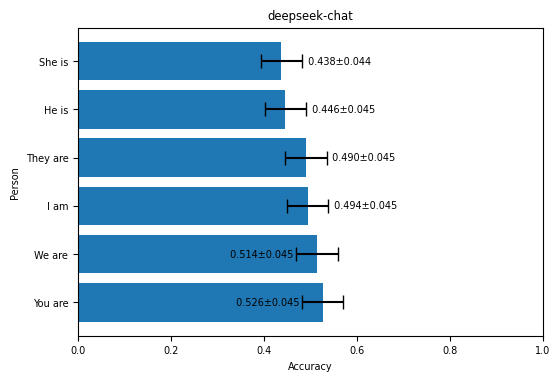

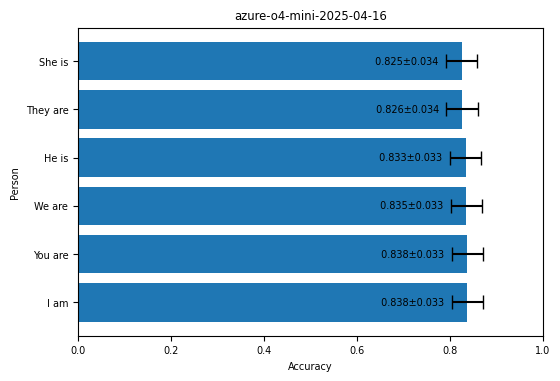

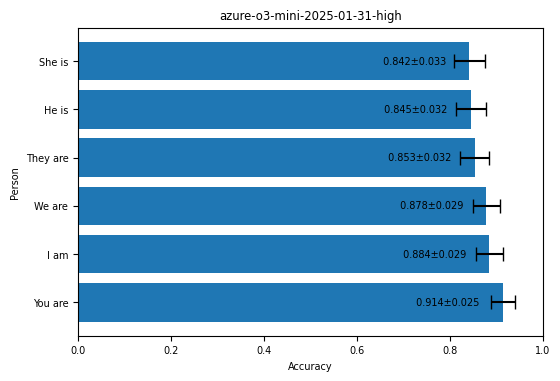

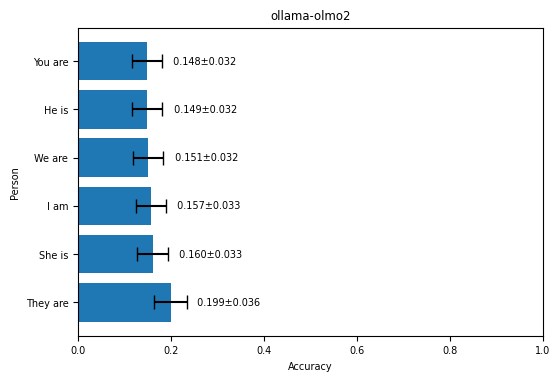

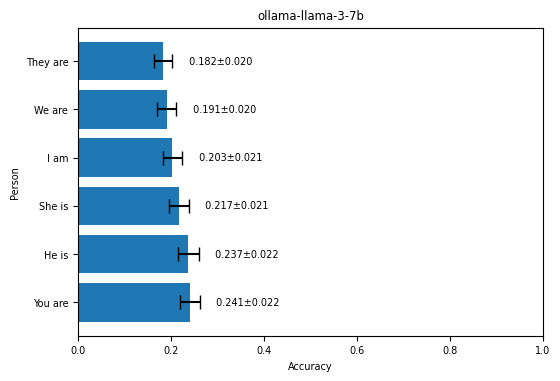

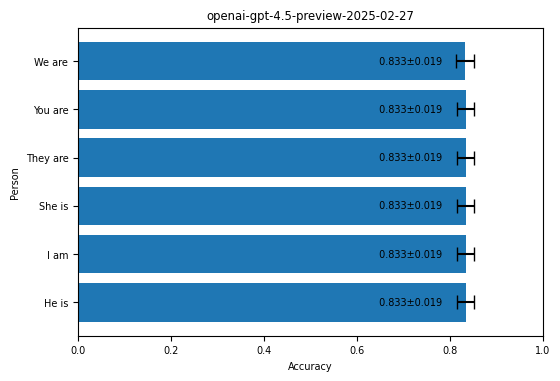

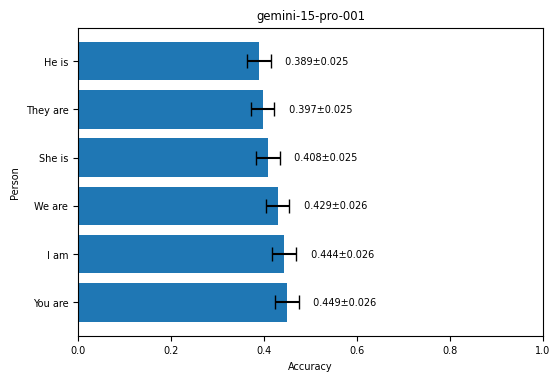

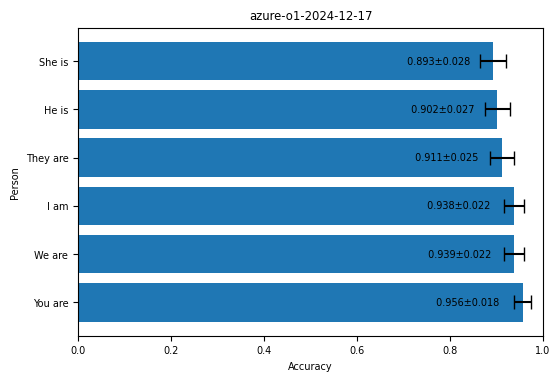

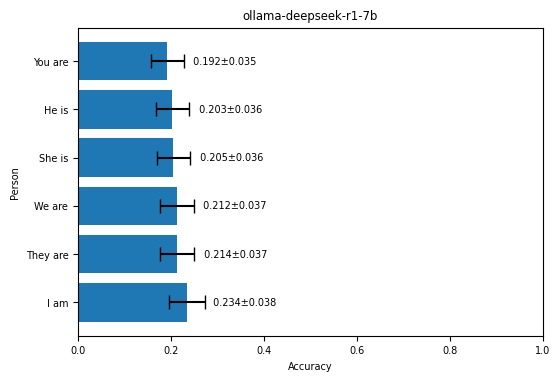

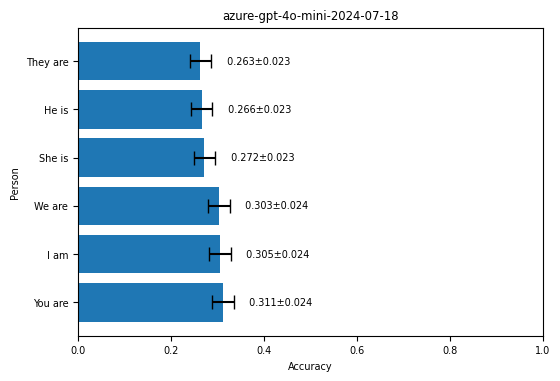

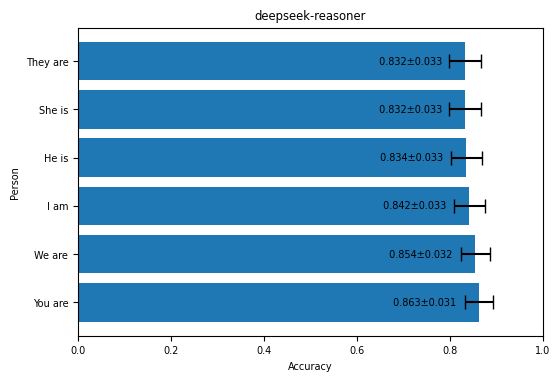

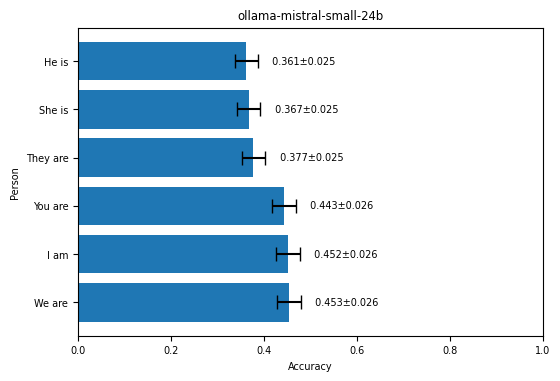

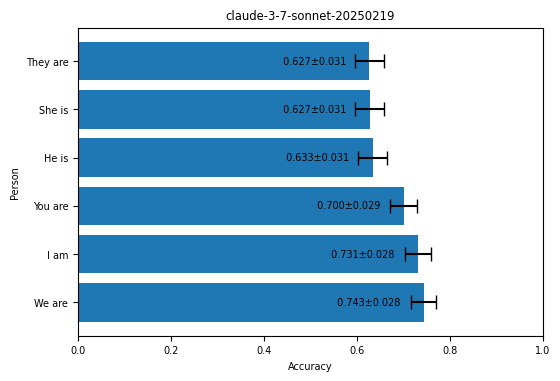

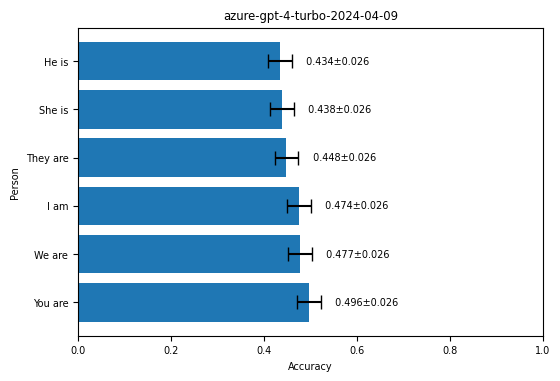

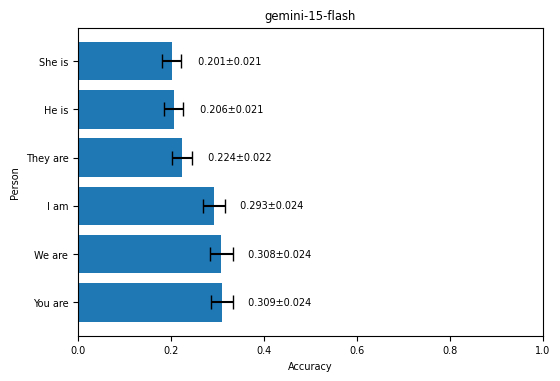

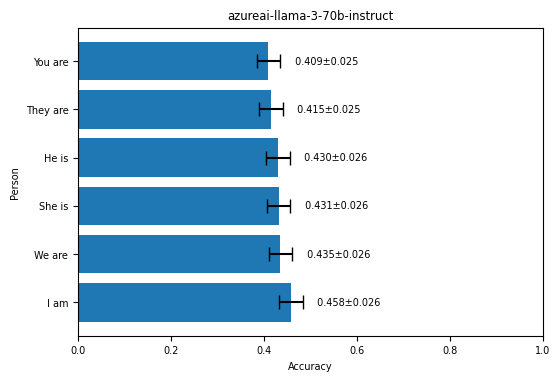

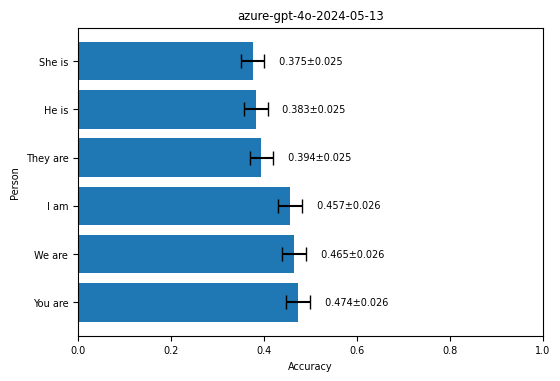

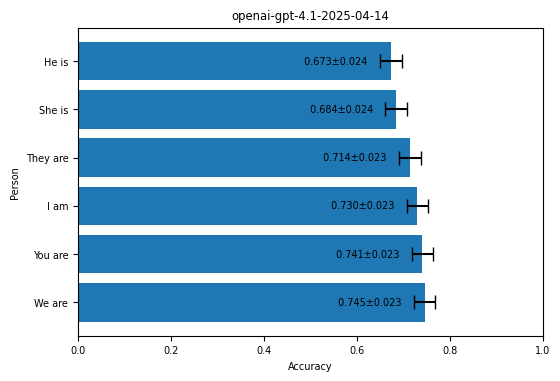

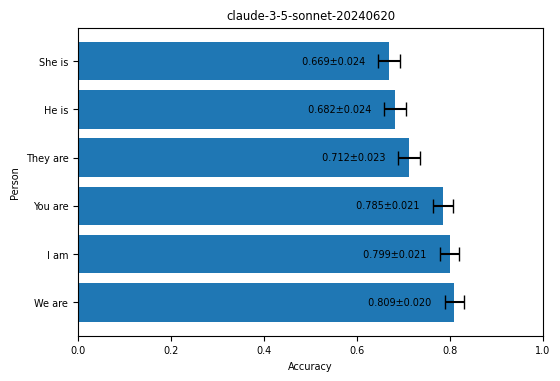

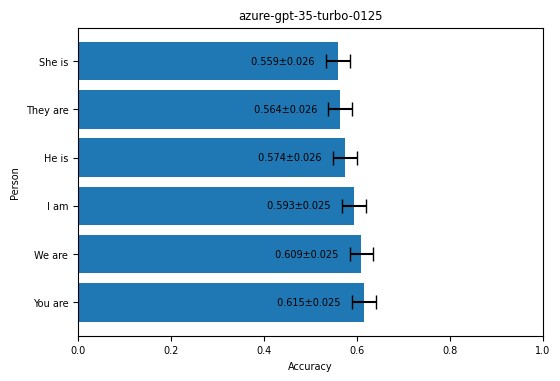

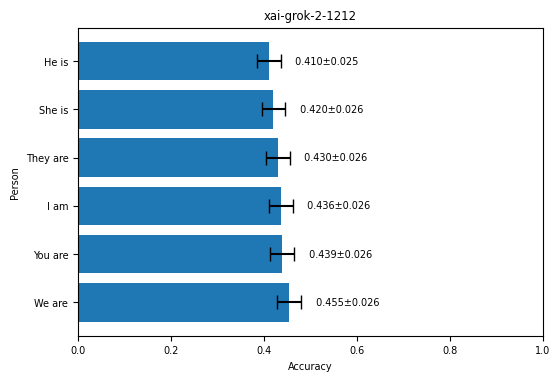

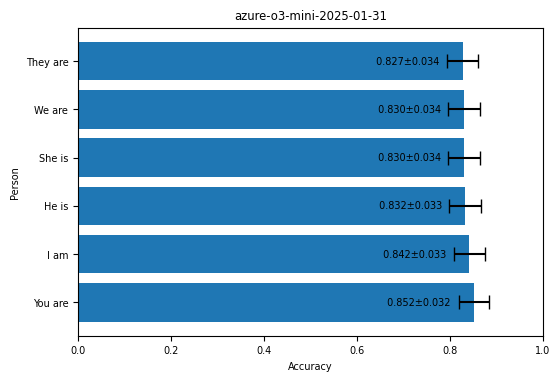

In [48]:
for model in df['model'].unique():
    plot_person(df, model)

model     azure-gpt-35-turbo-0125  azure-gpt-4-turbo-2024-04-09  \
person                                                            
He is                    0.573958                      0.433681   
I am                     0.593403                      0.474306   
She is                   0.559028                      0.438194   
They are                 0.563889                      0.448264   
We are                   0.609375                      0.477083   
You are                  0.614931                      0.496181   

model     azure-gpt-4o-2024-05-13  azure-gpt-4o-mini-2024-07-18  \
person                                                            
He is                    0.382986                      0.266319   
I am                     0.456597                      0.304514   
She is                   0.375347                      0.271875   
They are                 0.394097                      0.262847   
We are                   0.465278                      0.3027

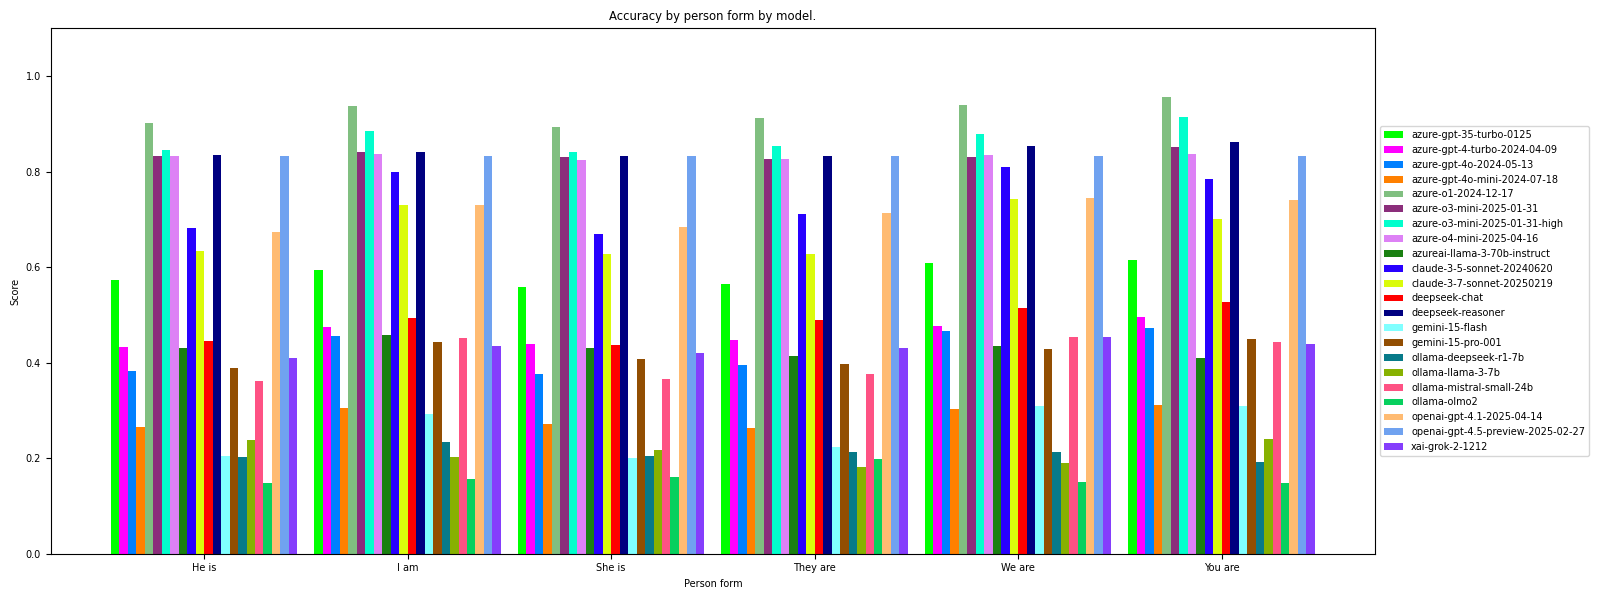

In [49]:
df3 = df.groupby(['person', 'model'])['score'].mean().unstack()
print(df3)
plot_grouped_bar_chart(df3, xlabel="Person form",title="Accuracy by person form by model.")

# Direction

  correctAnswer  mean_score  interval  n_score         label
0         south    0.818056  0.039948      720   0.818±0.040
1          east    0.691667  0.047818      720   0.692±0.048
2          west    0.601389  0.050697      720   0.601±0.051
3    south-east    0.534722  0.051648      720   0.535±0.052
4         north    0.475000  0.051708      720   0.475±0.052
5    north-east    0.400000  0.050727      720   0.400±0.051
6    north-west    0.223611  0.043144      720   0.224±0.043
7    south-west    0.130556  0.034886      720   0.131±0.035
  correctAnswer  mean_score  interval  n_score         label
0          east    0.848611  0.037113      720   0.849±0.037
1         north    0.845833  0.037391      720   0.846±0.037
2          west    0.844444  0.037528      720   0.844±0.038
3         south    0.838889  0.038067      720   0.839±0.038
4    north-east    0.829167  0.038971      720   0.829±0.039
5    north-west    0.826389  0.039220      720   0.826±0.039
6    south-west    0.813

/Users/rblackwell/git/cosit-2024-evaluating-the-ability-of-llms-to-reason-about-cardinal-directions/notebooks/utils.py:268: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 4))


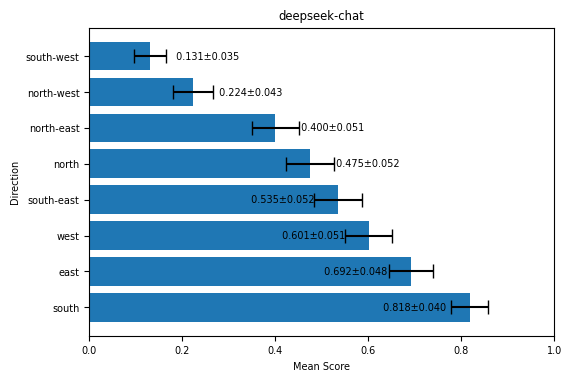

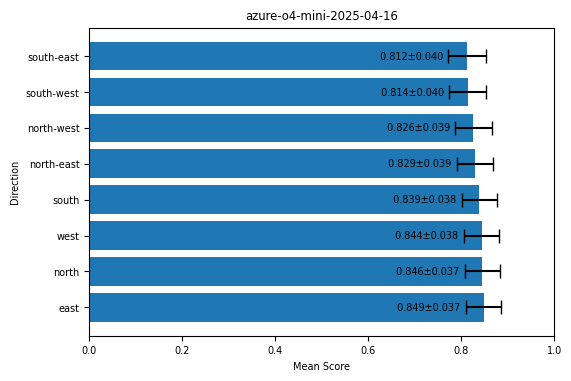

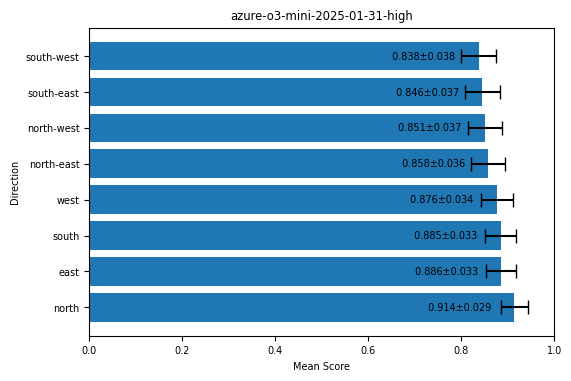

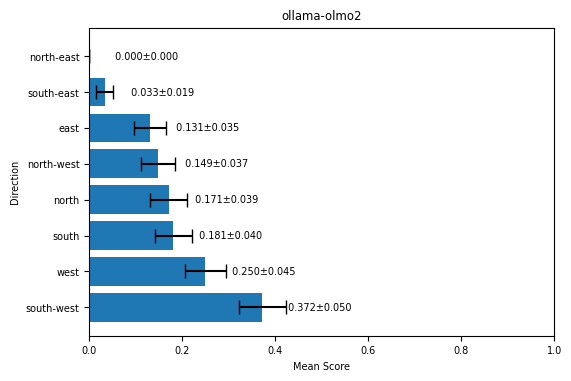

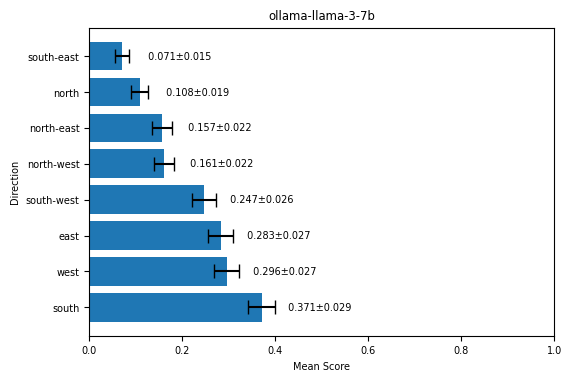

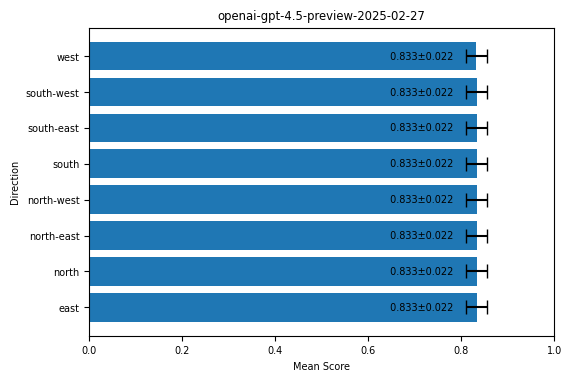

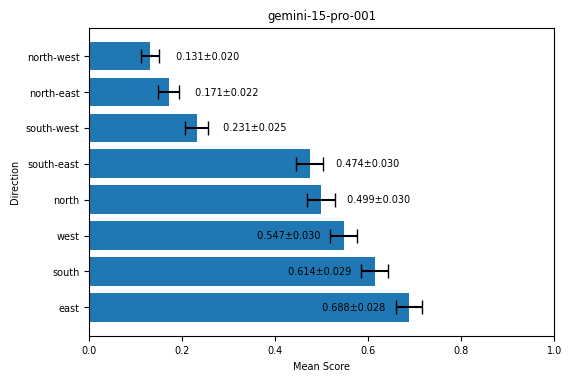

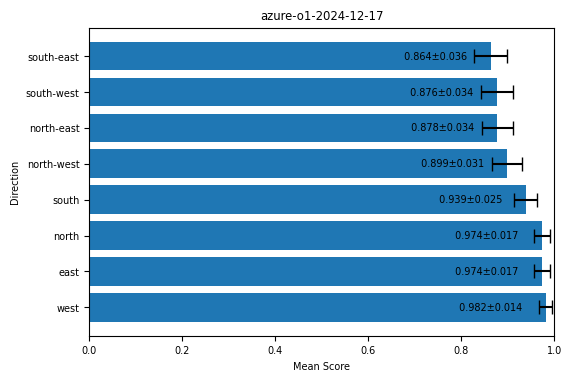

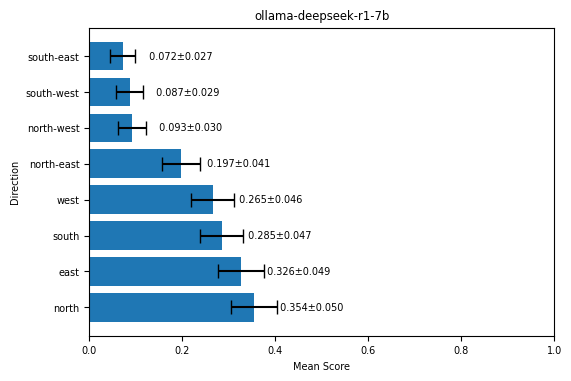

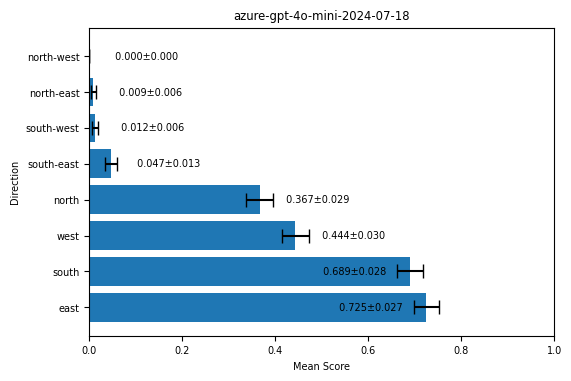

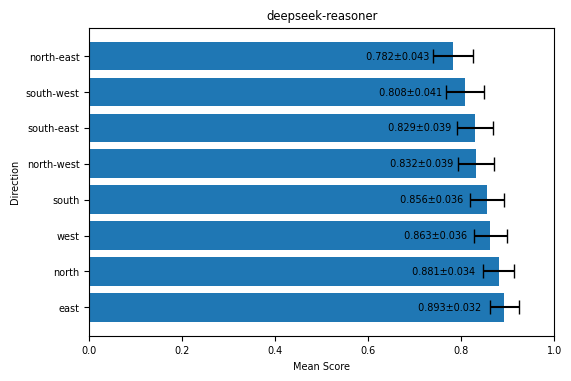

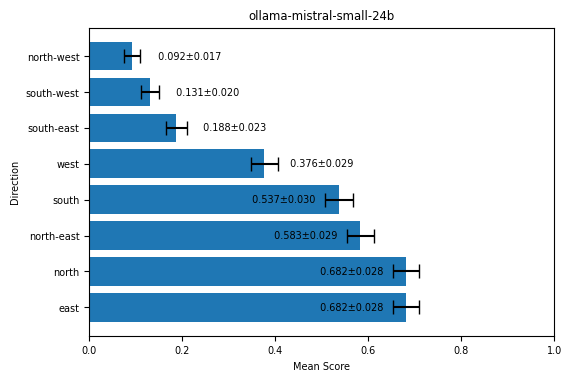

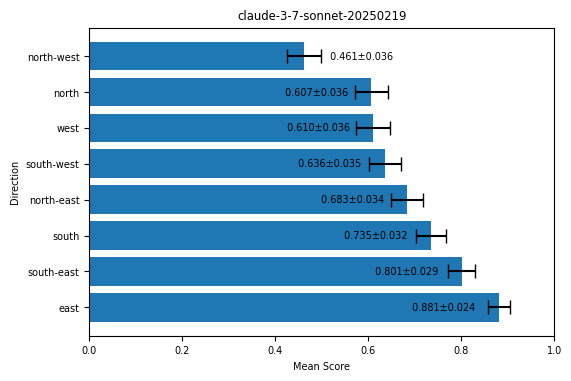

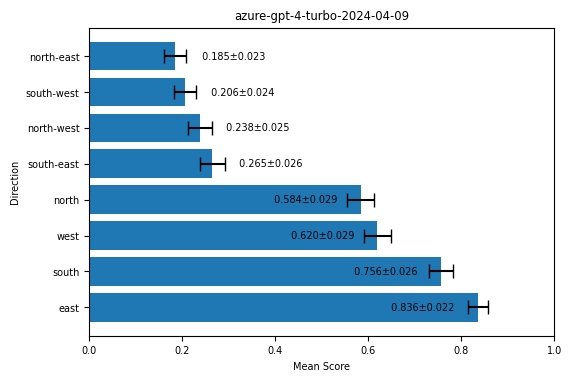

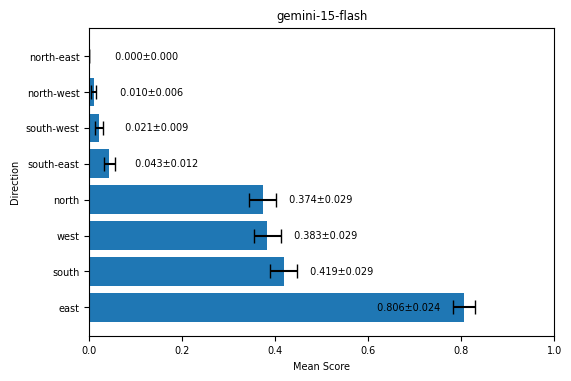

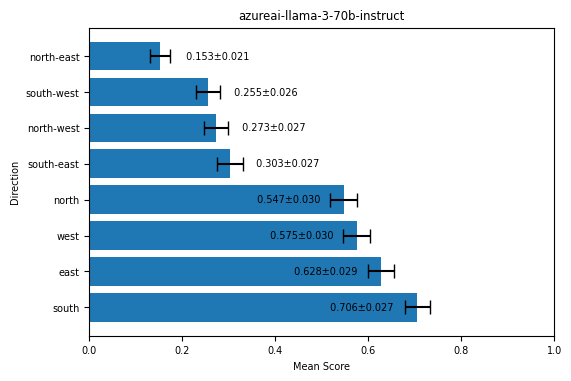

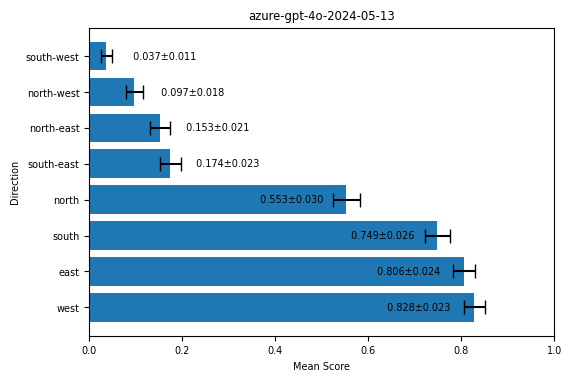

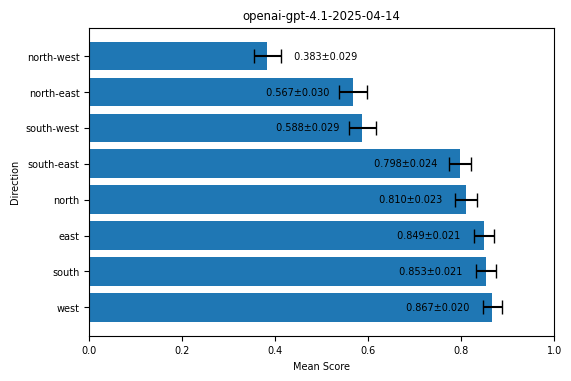

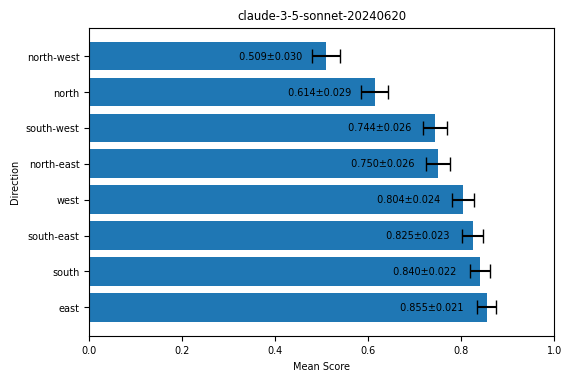

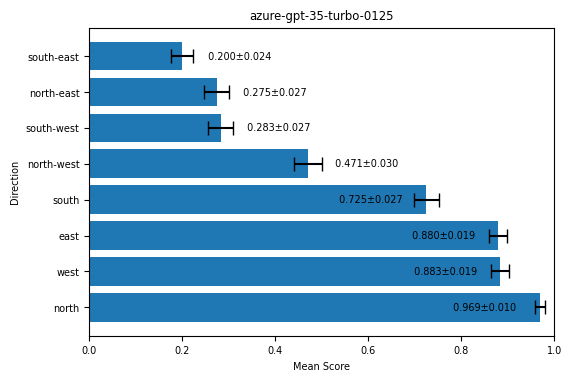

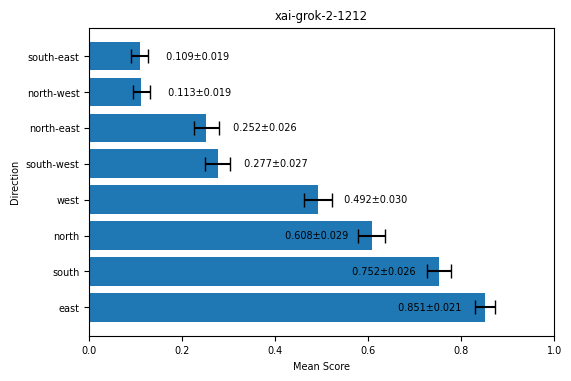

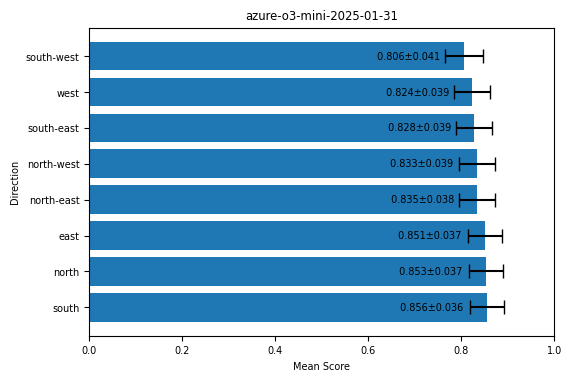

In [50]:
for model in df['model'].unique():
    plot_direction(df, model)

model          azure-gpt-35-turbo-0125  azure-gpt-4-turbo-2024-04-09  \
correctAnswer                                                          
east                          0.880093                      0.836111   
north                         0.968981                      0.583796   
north-east                    0.274537                      0.185185   
north-west                    0.471296                      0.237963   
south                         0.725463                      0.756481   
south-east                    0.199537                      0.264815   
south-west                    0.282870                      0.206019   
west                          0.883333                      0.619907   

model          azure-gpt-4o-2024-05-13  azure-gpt-4o-mini-2024-07-18  \
correctAnswer                                                          
east                          0.806019                      0.725463   
north                         0.553241                      0.3

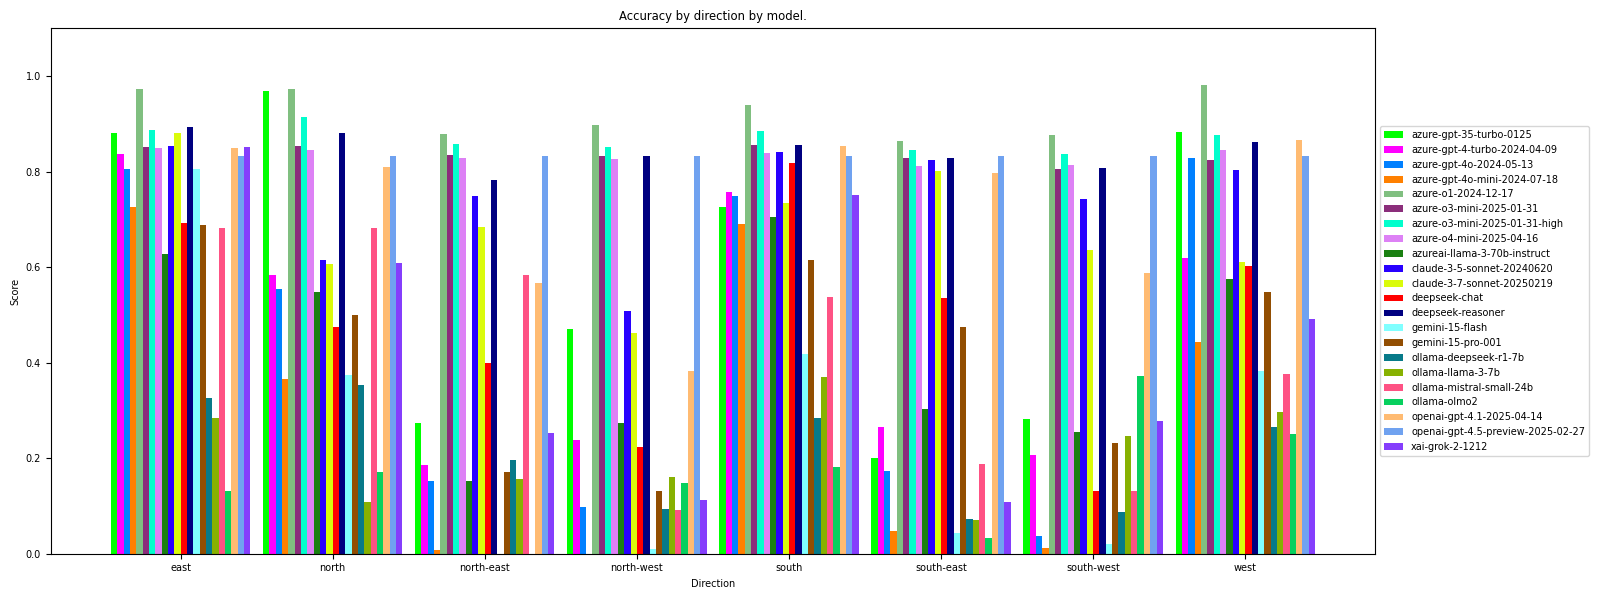

In [51]:
df3 = df.groupby(['correctAnswer', 'model'])['score'].mean().unstack()
print(df3)
plot_grouped_bar_chart(df3, xlabel="Direction",title="Accuracy by direction by model.")

# Template

In [52]:

template_mapping = {
    "t1": 'T1 You are walking [south] along the [east] shore of a lake; in which direction is the lake?',
    "t2": 'T2 You are walking [south] along the [east] shore of a lake and then turn around to head back in the direction you came from, in which direction is the lake?',
    "t3": 'T3 You are walking [south] along the middle of the [east] side of a park; in which direction is the bandstand located in the centre of the park?',
    "t4": 'T4 You are walking [east] along the [south] side of a road which runs [east to west]. In which direction is the road?',
    "t5": 'T5 You are walking [south] along the [east] shore of the island. In which direction is the sea?',
    "t6": 'T6 You are walking [south] along the [east] shore of an island and then turn around to head back in the direction you came from, in which direction is the sea?'
}

df2 = df.copy()
# Apply the mapping to the 'person' column
df2['template'] = df2['template'].map(template_mapping)


/Users/rblackwell/git/cosit-2024-evaluating-the-ability-of-llms-to-reason-about-cardinal-directions/notebooks/utils.py:952: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 4))


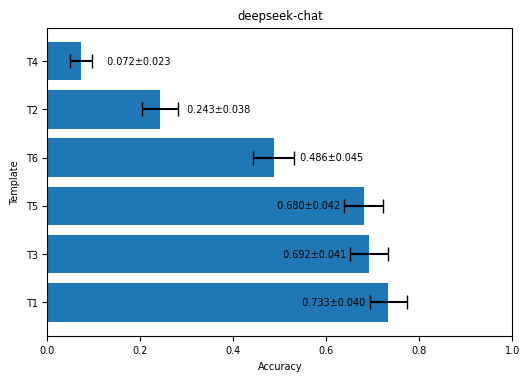

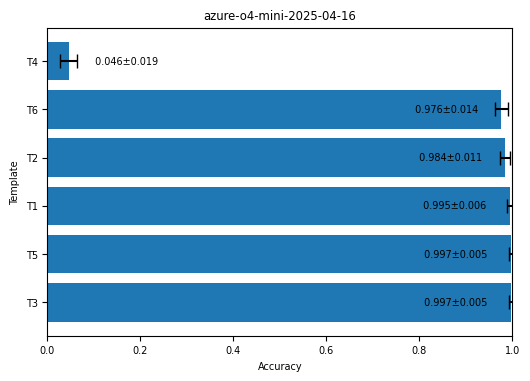

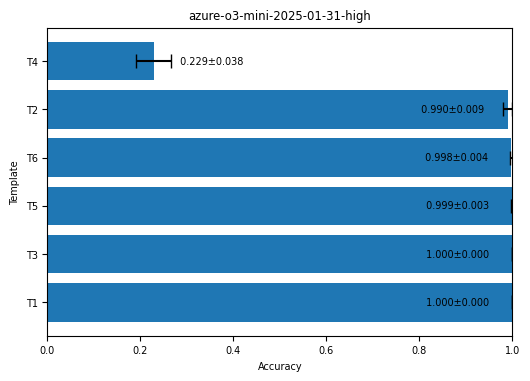

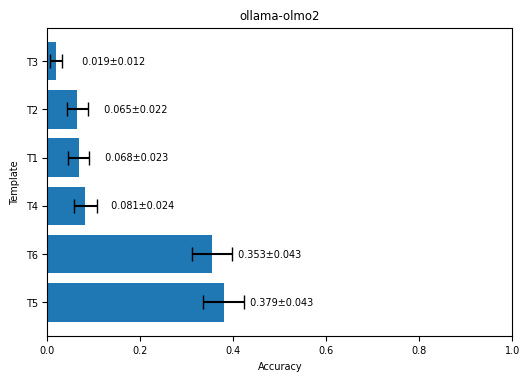

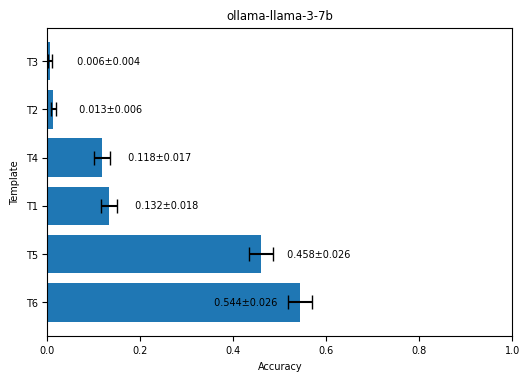

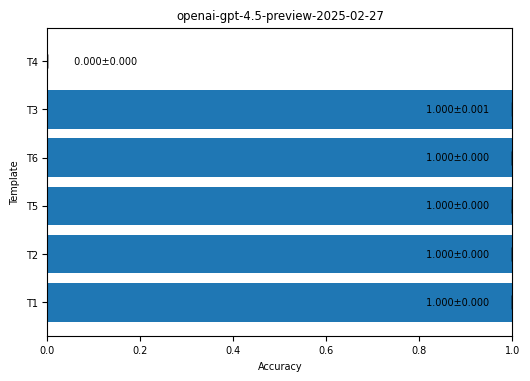

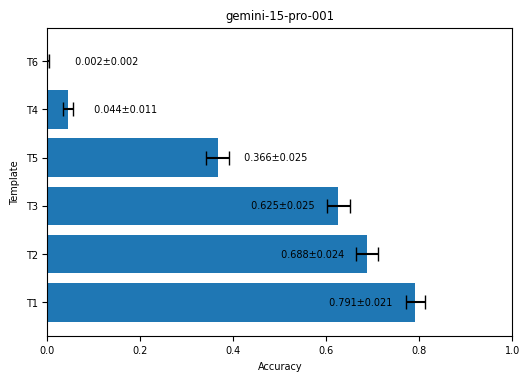

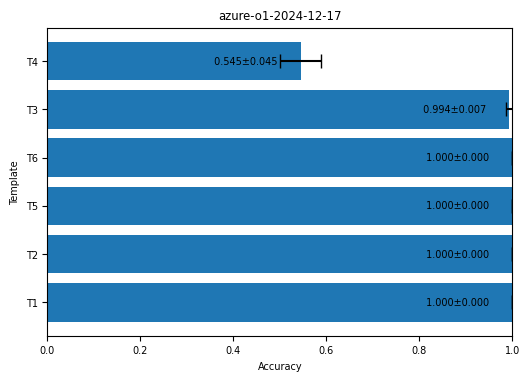

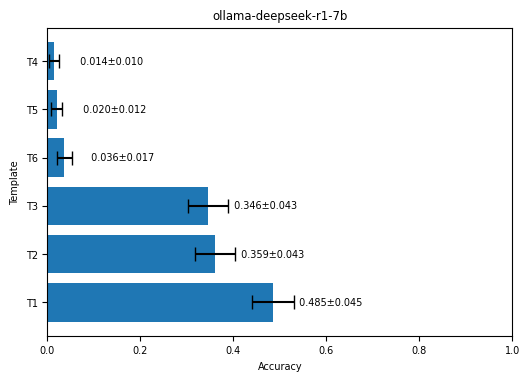

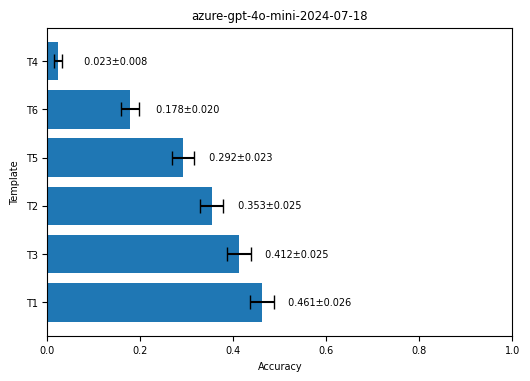

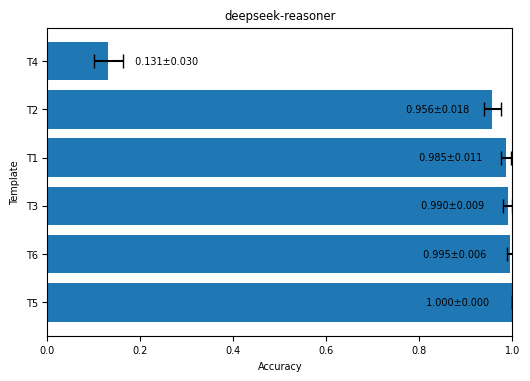

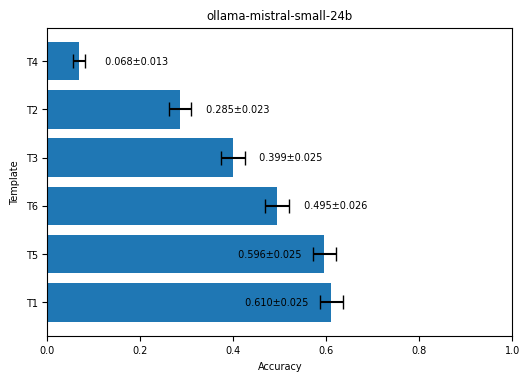

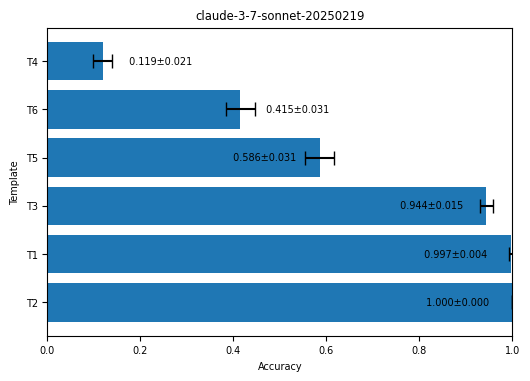

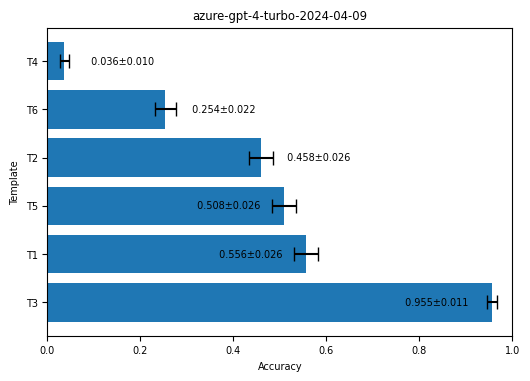

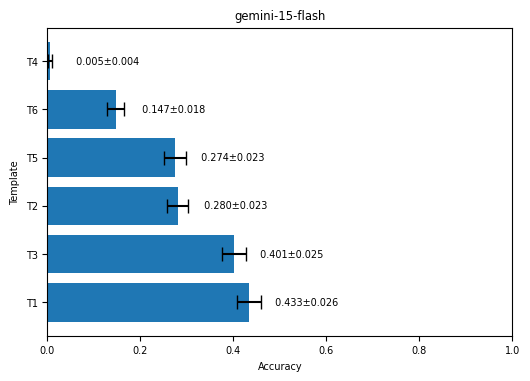

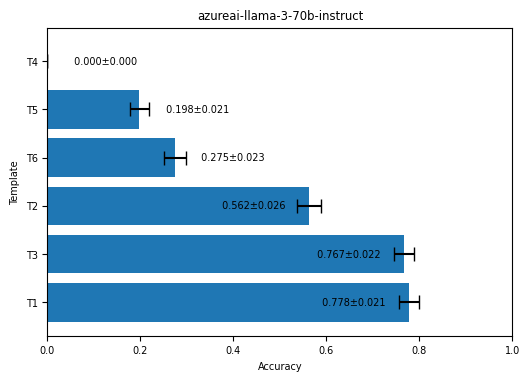

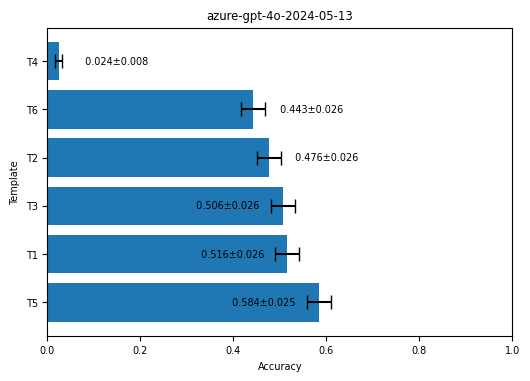

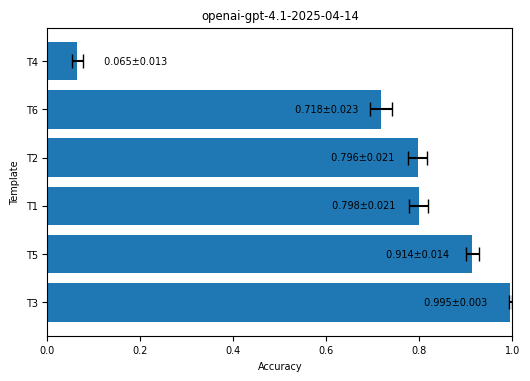

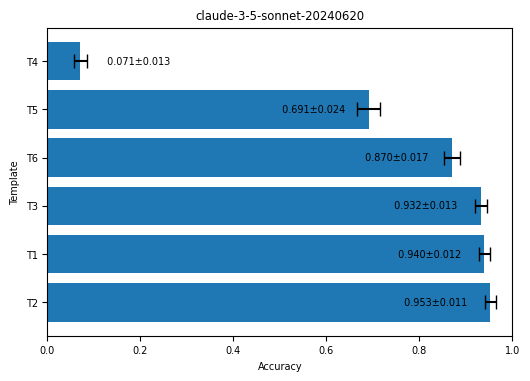

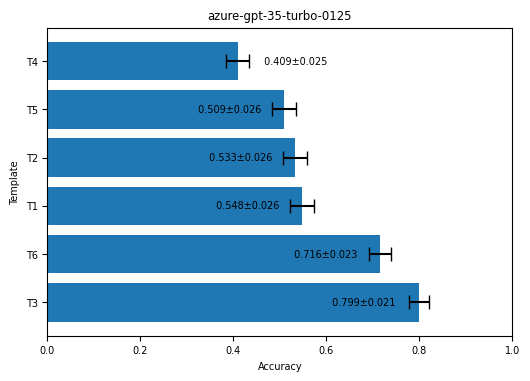

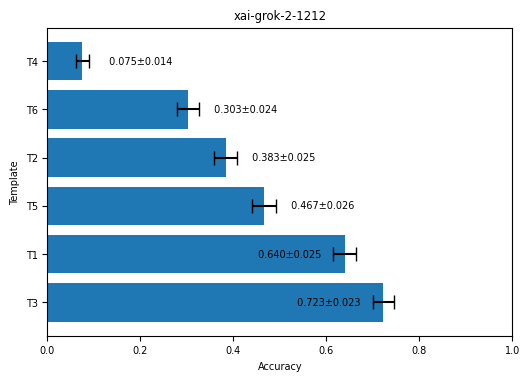

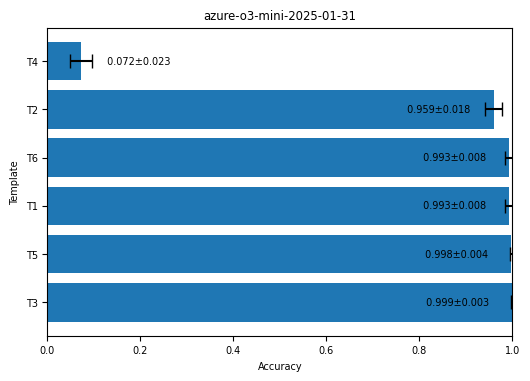

In [53]:
for model in df2['model'].unique():
    plot_template(df2, model)

model     azure-gpt-35-turbo-0125  azure-gpt-4-turbo-2024-04-09  \
template                                                          
t1                       0.548264                      0.555556   
t2                       0.532986                      0.458333   
t3                       0.798958                      0.955208   
t4                       0.409028                      0.036458   
t5                       0.509375                      0.508333   
t6                       0.715972                      0.253819   

model     azure-gpt-4o-2024-05-13  azure-gpt-4o-mini-2024-07-18  \
template                                                          
t1                       0.515625                      0.461111   
t2                       0.475694                      0.353472   
t3                       0.505903                      0.412153   
t4                       0.023958                      0.022917   
t5                       0.583681                      0.2916

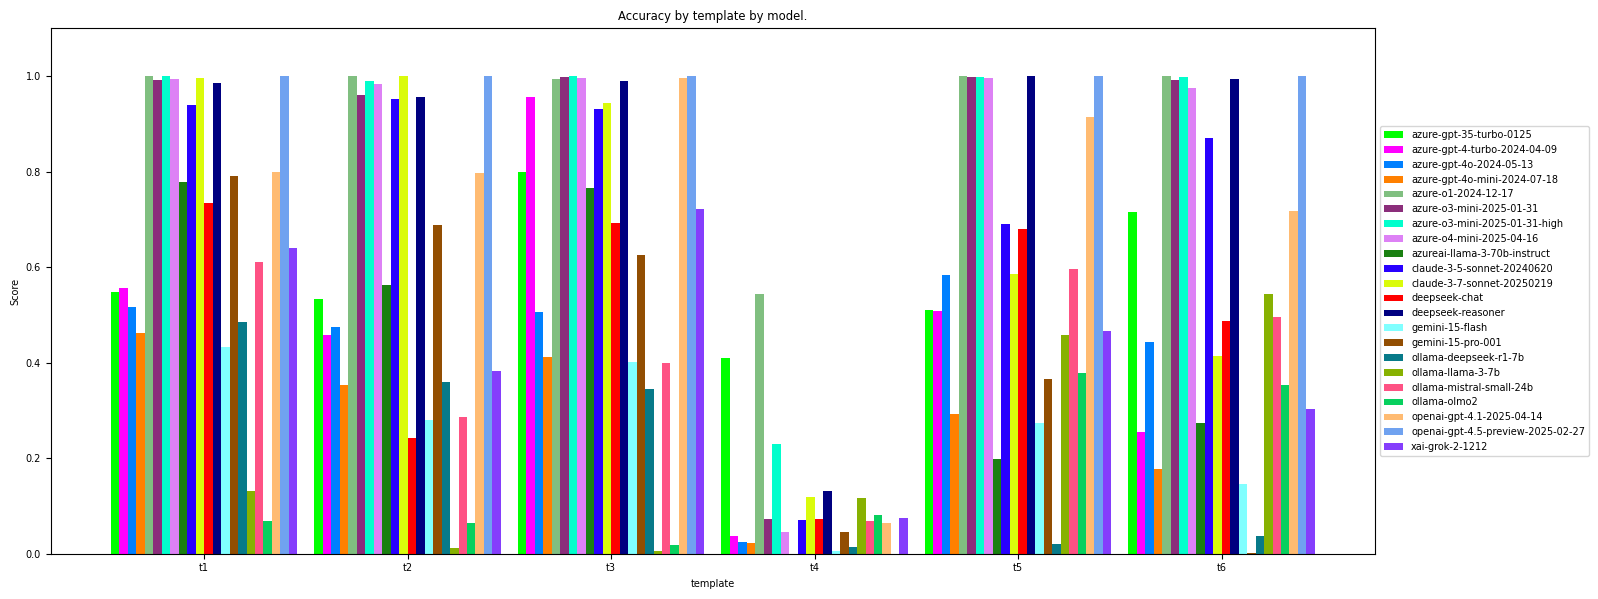

In [54]:
df3 = df.groupby(['template', 'model'])['score'].mean().unstack()
print(df3)
plot_grouped_bar_chart(df3,title="Accuracy by template by model.")

  correctAnswer  mean_score  interval  n_score         label
0          west    0.981944  0.013787      720   0.982±0.014
1          east    0.973611  0.016597      720   0.974±0.017
2         north    0.973611  0.016597      720   0.974±0.017
3         south    0.938889  0.024803      720   0.939±0.025
4    north-west    0.898611  0.031254      720   0.899±0.031
5    north-east    0.877778  0.033915      720   0.878±0.034
6    south-west    0.876389  0.034081      720   0.876±0.034
7    south-east    0.863889  0.035506      720   0.864±0.036


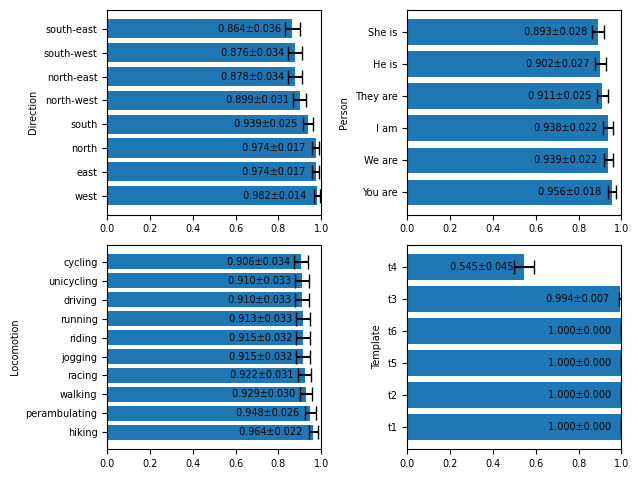

In [55]:
fig, axes = plt.subplots(2, 2)

plot_direction(df, 'azure-o1-2024-12-17', ax=axes[0, 0],show_xlabel=False, show_title=False)
plot_person(df, 'azure-o1-2024-12-17', ax=axes[0, 1],show_xlabel=False, show_title=False)
plot_locomotion(df, 'azure-o1-2024-12-17', ax=axes[1, 0],show_xlabel=False, show_title=False)
plot_template(df, 'azure-o1-2024-12-17', ax=axes[1, 1],show_xlabel=False, show_title=False)

plt.tight_layout()

plt.show()

In [56]:
wanted = ['azure-o1-2024-12-17','deepseek-reasoner','ollama-mistral-small-24b','deepseek-chat','azure-gpt-35-turbo-0125','openai-gpt-4.5-preview-2025-02-27','azureai-llama-3-70b-instruct']

In [57]:
df2 = df.copy()[df['model'].isin(wanted)]

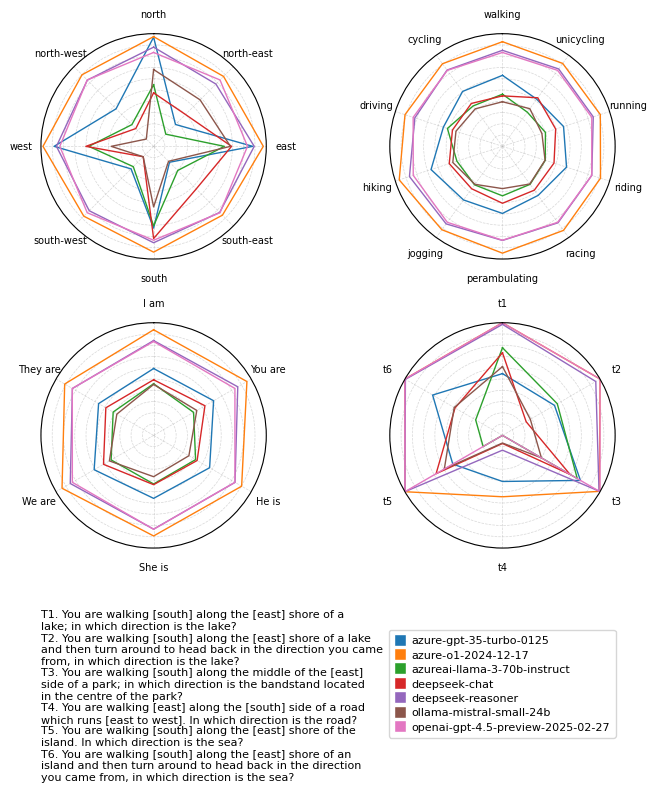

In [58]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(6.5, 8))
gs = GridSpec(3, 2, height_ratios=[3.25, 3.25, 1.5])  # Legend gets less vertical space

ax0 = fig.add_subplot(gs[0], projection='polar')
ax1 = fig.add_subplot(gs[1], projection='polar')
ax2 = fig.add_subplot(gs[2], projection='polar')
ax3 = fig.add_subplot(gs[3], projection='polar')
ax4 = fig.add_subplot(gs[4])
ax5 = fig.add_subplot(gs[5])

plot_direction_all_models_radar(df2,ax=ax0, show_title=False)

plot_locomotion_all_models_radar(df2,ax=ax1, show_title=False)
plot_person_all_models_radar(df2,ax=ax2, show_title=False)
plot_template_all_models_radar(df2, ax=ax3, show_title=False)
plot_template_bullets(ax=ax4)
plot_model_legend(df2, ax=ax5)

plt.tight_layout()
plt.savefig("../reports/figures/aspectsx.pdf", bbox_inches='tight', dpi=300)
plt.show()

<PolarAxes: >

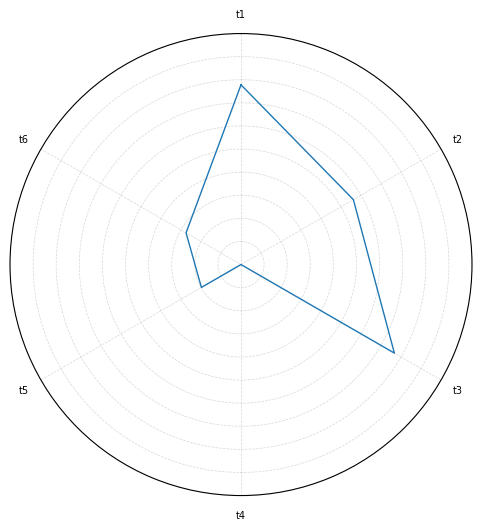

In [59]:
df2 = df.copy()[df['model'].isin(['azureai-llama-3-70b-instruct'])]
plot_template_all_models_radar(df2, show_title=False)


### Explore GPT4.5 approach to template T4

In [60]:
df['model'].unique()

array(['deepseek-chat', 'azure-o4-mini-2025-04-16',
       'azure-o3-mini-2025-01-31-high', 'ollama-olmo2',
       'ollama-llama-3-7b', 'openai-gpt-4.5-preview-2025-02-27',
       'gemini-15-pro-001', 'azure-o1-2024-12-17',
       'ollama-deepseek-r1-7b', 'azure-gpt-4o-mini-2024-07-18',
       'deepseek-reasoner', 'ollama-mistral-small-24b',
       'claude-3-7-sonnet-20250219', 'azure-gpt-4-turbo-2024-04-09',
       'gemini-15-flash', 'azureai-llama-3-70b-instruct',
       'azure-gpt-4o-2024-05-13', 'openai-gpt-4.1-2025-04-14',
       'claude-3-5-sonnet-20240620', 'azure-gpt-35-turbo-0125',
       'xai-grok-2-1212', 'azure-o3-mini-2025-01-31'], dtype=object)

In [61]:
df['template'].unique()

array(['t1', 't2', 't3', 't4', 't5', 't6'], dtype=object)

In [62]:
df2 = df[(df['model'] == 'openai-gpt-4.5-preview-2025-02-27') & (df['template']== 't4') ].copy()

In [63]:
len(df2)

2880

In [64]:
sum(df2['correctAnswer'] == df2['cleanAnswer'])

0

It indeed, gets none of the answers correct.

In [65]:
def angle_between_directions(dir1, dir2):
    direction_to_angle = {
        'north': 0,
        'north-east': 45,
        'east': 90,
        'south-east': 135,
        'south': 180,
        'south-west': 225,
        'west': 270,
        'north-west': 315
    }

    angle1 = direction_to_angle.get(dir1.lower())
    angle2 = direction_to_angle.get(dir2.lower())

    if angle1 is None or angle2 is None:
        return "Invalid direction(s)"

    # Calculate the absolute difference and ensure it's the smallest angle
    diff = abs(angle1 - angle2)
    return min(diff, 360 - diff)


In [66]:
len(df2)

2880

In [67]:

df2.apply(lambda row: angle_between_directions(row['correctAnswer'], row['cleanAnswer']),axis=1).value_counts()


90                      2614
Invalid direction(s)     266
Name: count, dtype: int64

In [68]:
2614/2880

0.9076388888888889

So 91% of the time it gives an answer 90 degrees off (i.e. consistent with the road direction). The remainder of the time it gives an invalid answer echoing the road description, e.g. north-south.

### Do LLMs confuse lake and sea directions?

Let's look at the templates involving lake (T1,T2) and island (T5,T6), for each model.

In [69]:
len(df['model'].unique())

22

In [70]:
for model in df['model'].unique():
    print(f"## {model}")
    df2 = df[(df['model'] == model) & df['template'].isin(['t1', 't2', 't5', 't6'])].copy()
    print(df2.apply(lambda row: angle_between_directions(row['correctAnswer'], row['cleanAnswer']),axis=1).value_counts())

## deepseek-chat
0      2057
90     1166
180     617
Name: count, dtype: int64
## azure-o4-mini-2025-04-16
0                       3794
180                       44
Invalid direction(s)       2
Name: count, dtype: int64
## azure-o3-mini-2025-01-31-high
0      3827
180      12
90        1
Name: count, dtype: int64
## ollama-olmo2
90     1835
180    1134
0       830
45       26
135      15
Name: count, dtype: int64
## ollama-llama-3-7b
90                      3762
0                       3303
180                     2574
Invalid direction(s)     996
45                       504
135                      381
Name: count, dtype: int64
## openai-gpt-4.5-preview-2025-02-27
0    11520
Name: count, dtype: int64
## gemini-15-pro-001
0      5319
180    3836
90     1744
45      447
135     174
Name: count, dtype: int64
## azure-o1-2024-12-17
0    3840
Name: count, dtype: int64
## ollama-deepseek-r1-7b
Invalid direction(s)    1092
0                        865
90                       753
180       

We might have expected LLMs to confuse the direction of the lake (T1,T2) and the sea (T5,T6), and 180 degrees is indeed the most common confusion for five models (o3-mini, o4-mini, Claude 3.5 Sonnet, Claude 3.7 sonnet, and gemini-15-pro), however in most cases (11 models) the most common confusion is 90 degrees from the correct answer suggesting that confusion is not systematic.

### Do models do better with cardinal directions than intercardinal directions?

In [71]:
df.columns

Index(['id', 'person', 'locomotion', 'question', 'absoluteAnswer', 'template',
       'correctAnswer', 'provider', 'model', 'timestamp', 'request',
       'response', 'answer', 'repeat', 'temperature', 'cleanAnswer', 'score',
       'colour'],
      dtype='object')

In [72]:
cardinal_directions = {'north', 'south', 'east', 'west'}

df['direction_type'] = df['absoluteAnswer'].apply(
    lambda x: 'cardinal' if x in cardinal_directions else 'intercardinal'
)

#mean_scores = df.groupby('direction_type')['score'].mean().reset_index()

mean_scores = df.groupby(['model', 'direction_type'])['score'].mean().reset_index()

print(mean_scores)

                                model direction_type     score
0             azure-gpt-35-turbo-0125       cardinal  0.864468
1             azure-gpt-35-turbo-0125  intercardinal  0.307060
2        azure-gpt-4-turbo-2024-04-09       cardinal  0.699074
3        azure-gpt-4-turbo-2024-04-09  intercardinal  0.223495
4             azure-gpt-4o-2024-05-13       cardinal  0.734028
5             azure-gpt-4o-2024-05-13  intercardinal  0.115278
6        azure-gpt-4o-mini-2024-07-18       cardinal  0.556250
7        azure-gpt-4o-mini-2024-07-18  intercardinal  0.016898
8                 azure-o1-2024-12-17       cardinal  0.967014
9                 azure-o1-2024-12-17  intercardinal  0.879167
10           azure-o3-mini-2025-01-31       cardinal  0.845833
11           azure-o3-mini-2025-01-31  intercardinal  0.825347
12      azure-o3-mini-2025-01-31-high       cardinal  0.890278
13      azure-o3-mini-2025-01-31-high  intercardinal  0.848264
14           azure-o4-mini-2025-04-16       cardinal  0

All models except GPT4.5 had higher overall accuracy with cardinal than intercardinal directions, though there were some notably strange results such as with Claude Sonnet where South East had higher accuracy than North (Claude Sonnet 3.5: 0.825 / 0.614, Claude Sonnet 3.7: 0.801 / 0.607)